# 📘 Lecture 5: Univariate Probability Models, Frequentist vs. Bayesian Perspectives, Conditional Moments & Anscombe's Quartet
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 5 - YouTube](https://youtu.be/CH2U18ajm3g?si=kRGyk-zdgxQ7By0_)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we explore the foundational probability concepts required for machine learning and probabilistic graphical models:
1. **Frequentist vs. Bayesian Interpretations**: Repeated trial limiting frequencies vs. degree-of-belief under uncertainty (e.g. coin tosses vs. single-event climate prediction).
2. **Epistemic vs. Aleatoric Uncertainty & Active Learning**: Model ignorance vs. intrinsic data randomness; entropy-driven sample querying.
3. **Boolean Logic & Event Spaces**: Joint probabilities, Chain Rule of Probability, Marginal vs. Conditional Independence (Mediation graphs).
4. **Discrete vs. Continuous Random Variables**: Probability Mass Functions (PMF), Cumulative Distribution Functions (CDF), Probability Density Functions (PDF), Quantiles, and 95% Confidence Intervals.
5. **Summary Statistics**: Linearity of Expectation, Variance of Product of Independent Variables, and Mode vs. Mean in spiky distributions.
6. **Law of Total Expectation & Law of Total Variance (Eve's Law)**: Decomposing total variance into within-cluster variance and between-cluster variance using Gaussian Mixture Models (GMM) with interactive visual diagrams.
7. **Anscombe's Quartet**: Why low-order summary statistics fail to distinguish distinct spatial data distributions, emphasizing data visualization.

---


## 0️⃣ Environment Setup & Imports
We start by importing standard Python scientific computation and data visualization packages.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.1.3


## 1️⃣ Interpretations of Probability: Frequentist vs. Bayesian

### 1.1 Mathematical Formalism
- **Frequentist Perspective**: Defines the probability of an event $A$ as the limiting relative frequency over infinite repeated trials under identical conditions:
  $$P_{\text{freq}}(A) = \lim_{N \to \infty} \frac{N_A}{N}$$
- **Bayesian Perspective**: Defines probability as a quantified **degree of belief** or subjective certainty about a proposition given available information $\mathcal{H}$:
  $$P_{\text{Bayes}}(A \mid \mathcal{H}) \in [0, 1]$$
  *Example*: "The probability that polar ice caps melt by 2030." Because this is a unique historical event, repeated physical trials $N \to \infty$ are impossible, necessitating the Bayesian subjective framework.


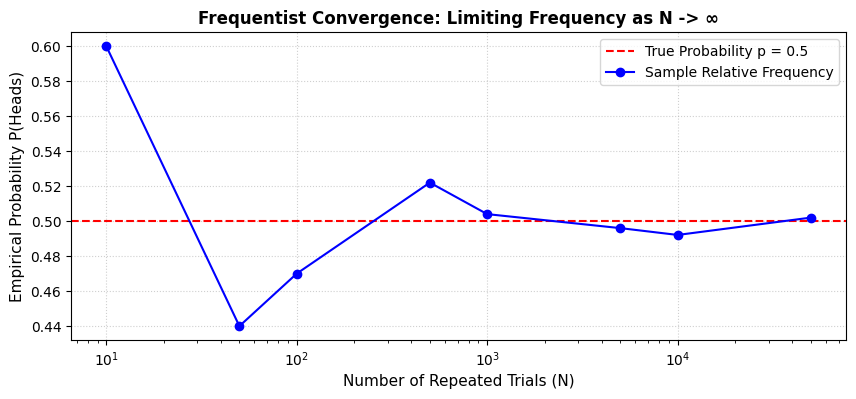

📊 Frequentist Convergence Values across Trial Counts:
   N =     10 trials -> Empirical P(Heads) = 0.6000
   N =     50 trials -> Empirical P(Heads) = 0.4400
   N =    100 trials -> Empirical P(Heads) = 0.4700
   N =    500 trials -> Empirical P(Heads) = 0.5220
   N =   1000 trials -> Empirical P(Heads) = 0.5040
   N =   5000 trials -> Empirical P(Heads) = 0.4960
   N =  10000 trials -> Empirical P(Heads) = 0.4921
   N =  50000 trials -> Empirical P(Heads) = 0.5020


In [2]:
# Simulation of Frequentist Coin Toss Convergence (Law of Large Numbers)
#Start code here..
true_p = 0.5
trial_counts = np.array([10, 50, 100, 500, 1000, 5000, 10000, 50000])
sample_means = []

for N in trial_counts:
    #let us simulate N bernoulli trials (coin tosses)
    tosses = np.random.binomial(n=1, p=true_p, size=N)
    sample_means.append(np.mean(tosses))

##End code here..
plt.figure(figsize=(10, 4))
plt.axhline(true_p, color='red', linestyle='--', label='True Probability p = 0.5')
plt.plot(trial_counts, sample_means, marker='o', color='blue', label='Sample Relative Frequency')
plt.xscale('log')
plt.xlabel('Number of Repeated Trials (N)', fontsize=11)
plt.ylabel('Empirical Probability P(Heads)', fontsize=11)
plt.title('Frequentist Convergence: Limiting Frequency as N -> ∞', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("📊 Frequentist Convergence Values across Trial Counts:")
for n, m in zip(trial_counts, sample_means):
    print(f"   N = {n:6d} trials -> Empirical P(Heads) = {m:.4f}")


## 2️⃣ Epistemic vs. Aleatoric Uncertainty & Active Learning

### 2.1 Taxonomy of Uncertainty
1. **Epistemic Uncertainty (Model Ignorance)**: Uncertainty arising from a lack of data or knowledge about the true data generating process $p^*(\mathbf{x}, y)$. This uncertainty is **reducible** as more training data is observed.
2. **Aleatoric Uncertainty (Data Irreducibility)**: Inherent stochastic noise in the physical observation system (e.g. coin flip variance or sensor noise). This uncertainty is **irreducible** even with infinite data.

### 2.2 Active Learning & Shannon Entropy Querying
In Active Learning, the model selects unlabelled instances $\mathbf{x}^*$ from a pool to be annotated by an oracle by maximizing the **Shannon Entropy** of the predicted output distribution:
$$\mathbf{x}^* = \arg\max_{\mathbf{x}} H(Y \mid \mathbf{x}) = \arg\max_{\mathbf{x}} \left( - \sum_{c=1}^C P(Y=c \mid \mathbf{x}) \log_2 P(Y=c \mid \mathbf{x}) \right)$$
High entropy indicates maximum model epistemic uncertainty, making that query most informative.

In [4]:
#Start code here..
#Simulation of active learning entropy based querying
def shannon_entropy(probs):
    """Calculates H(Y|x) : high value means high uncertainty"""
    probs = np.array(probs)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

#Scenarios: High certainty vs max uncertainty

candidate_predictions = {
    'Sample A (high confidence)' : [0.95,0.03,0.02],
    'Sample B (moderate uncertainty)' : [0.60, 0.30, 0.10],
    'Sample C (maximum epistemic uncertainty)' : [0.34,0.33,0.33]
}

print("Active learning query selection via shannon entropy H(Y|x)")
entropies = {}
for name, probs in candidate_predictions.items():
    H = shannon_entropy(probs)
    entropies[name] = H
    print(f" {name}: Probs = {probs} -> Entropy H = {H:.4f} bits")

#The strategy: We ask the human to label the sample where the model is most confused
selected_query = max(entropies, key=entropies.get)
print(f"\n Active learning strategy selects : [{selected_query}] for oracle annotation!")

#End code here..


Active learning query selection via shannon entropy H(Y|x)
 Sample A (high confidence): Probs = [0.95, 0.03, 0.02] -> Entropy H = 0.3349 bits
 Sample B (moderate uncertainty): Probs = [0.6, 0.3, 0.1] -> Entropy H = 1.2955 bits
 Sample C (maximum epistemic uncertainty): Probs = [0.34, 0.33, 0.33] -> Entropy H = 1.5848 bits

 Active learning strategy selects : [Sample C (maximum epistemic uncertainty)] for oracle annotation!


## 3️⃣ Joint Probabilities, Chain Rule & Conditional Independence

### 3.1 Chain Rule of Probability
For any joint distribution over $D$ random variables $(X_1, X_2, \dots, X_D)$, the joint density factors into a sequence of conditional distributions:
$$P(X_1, X_2, \dots, X_D) = P(X_1) \cdot P(X_2 \mid X_1) \cdot P(X_3 \mid X_1, X_2) \dots P(X_D \mid X_1, \dots, X_{D-1}) = \prod_{d=1}^D P(X_d \mid X_1, \dots, X_{d-1})$$

### 3.2 Marginal vs. Conditional Independence (Mediation Model)
- **Marginal Independence**: $A \perp B \iff P(A, B) = P(A)P(B)$. Unconditional independence is rare in practice.
- **Conditional Independence**: $A \perp B \mid C \iff P(A, B \mid C) = P(A \mid C)P(B \mid C)$.

#### Weather Mediation Example:
Consider Weather $Z \in \{\text{Rain}, \text{Sunny}\}$, Carrying Umbrella $X \in \{0, 1\}$, and Ground Wetness $Y \in \{0, 1\}$.
- Unconditionally, seeing an umbrella $X=1$ makes wet ground $Y=1$ much more likely ($X \not\perp Y$).
- Conditioned on knowing the weather $Z=\text{Rain}$, observing $X$ provides no additional information about $Y$ ($X \perp Y \mid Z$).


In [7]:
##Start code here...
##Code verification of conditional independence in weather mediation network
#Z : latent cause (weather) , X & Y are the observed effects (Umbrella/wet ground)

#marginal probability of rain
p_Z = np.array([0.7,0.3])

#p(X|Z) : p(Effect|Cause)
p_X_given_Z = np.array([
    [0.95,0.05], #P(Umbrella|Sunny)
    [0.10, 0.90] #P(Umbrella|Rain)
])

p_Y_given_Z = np.array([
    [0.90, 0.10], #P(Wet | Sunny)
    [0.02, 0.98] #P(Wet | Rain)
])

#Test : Does P(X,Y|Z) = P(X|Z)*P(Y|Z)
px1_z1 = p_X_given_Z[1,1] # P(umbrella=1|Rain)
py1_z1 = p_Y_given_Z[1,1] # P(wet=1|Rain)
p_X_Y_given_Z = px1_z1 * py1_z1 #predicted joint probability if indpendent given Z
factored_p = px1_z1 * py1_z1

print("Weather Mediation Model - Conditional Independence Test")
print(f" P(X=1,Y=1|Z=Rain) = {p_X_Y_given_Z:.4f}")
print(f" P(X=1,Y=1|Z=Rain) = {factored_p:.4f}")
print(f" Difference = {p_X_Y_given_Z - factored_p:.4f}")



##End code here..


Weather Mediation Model - Conditional Independence Test
 P(X=1,Y=1|Z=Rain) = 0.8820
 P(X=1,Y=1|Z=Rain) = 0.8820
 Difference = 0.0000


## 4️⃣ Discrete vs. Continuous Random Variables, Quantiles & 95% Intervals

### 4.1 PMF vs. PDF & CDF
- **Discrete Random Variable**: Sample space $\mathcal{X}$ is finite or countably infinite. Probability Mass Function (PMF) $p(x) = P(X=x)$ satisfies $\sum_{x \in \mathcal{X}} p(x) = 1$.
- **Continuous Random Variable**: Sample space $\mathcal{X} = \mathbb{R}$. Point probability $P(X=x) = 0$. We define the Cumulative Distribution Function (CDF) $F(x)$ and Probability Density Function (PDF) $f(x)$:
  $$F(x) = P(X \le x), \quad f(x) = \frac{d}{dx} F(x), \quad P(a \le X \le b) = \int_a^b f(x) dx$$

### 4.2 Quantiles & 95% Central Interval
The $q$-th quantile $x_q$ is the inverse CDF value: $x_q = F^{-1}(q)$, such that $P(X \le x_q) = q$.

For a Gaussian distribution $X \sim \mathcal{N}(\mu, \sigma^2)$, the 95% central probability interval is bounded by quantiles $\alpha/2 = 0.025$ and $1 - \alpha/2 = 0.975$:
$$[x_{0.025}, x_{0.975}] = [\mu - 1.96 \sigma, \mu + 1.96 \sigma]$$


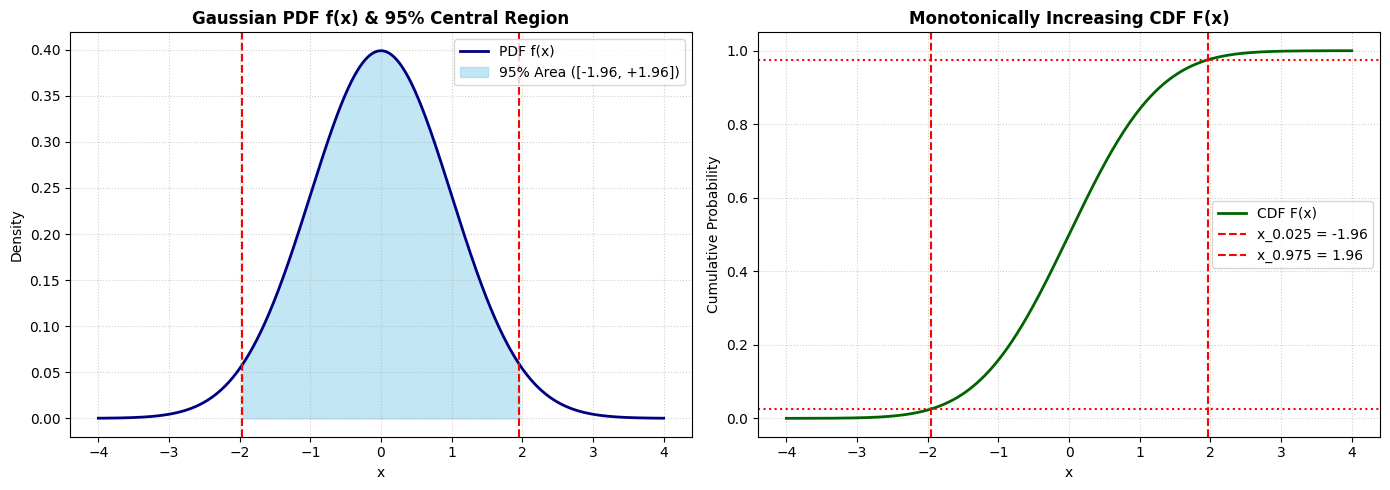

In [12]:
##Start code here..
# Plotting Gaussian PDF, CDF & 95% Confidence Interval Bounded by Quantiles
mu, sigma = 0.0, 1.0
x = np.linspace(-4,4,1000)
pdf = stats.norm.pdf(x, mu, sigma)
cdf = stats.norm.cdf(x, mu, sigma)

#percent point function (ppf) is the inverse of CDF (quantile function)
q_low = stats.norm.ppf(0.025, mu, sigma)
q_high = stats.norm.ppf(0.975, mu, sigma)
#End code here..

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF Plot
axes[0].plot(x, pdf, color='navy', linewidth=2, label='PDF f(x)')
axes[0].fill_between(x, pdf, where=(x >= q_low) & (x <= q_high), color='skyblue', alpha=0.5, label='95% Area ([-1.96, +1.96])')
axes[0].axvline(q_low, color='red', linestyle='--')
axes[0].axvline(q_high, color='red', linestyle='--')
axes[0].set_title('Gaussian PDF f(x) & 95% Central Region', fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# CDF Plot
axes[1].plot(x, cdf, color='darkgreen', linewidth=2, label='CDF F(x)')
axes[1].axhline(0.025, color='red', linestyle=':')
axes[1].axhline(0.975, color='red', linestyle=':')
axes[1].axvline(q_low, color='red', linestyle='--', label=f'x_0.025 = {q_low:.2f}')
axes[1].axvline(q_high, color='red', linestyle='--', label=f'x_0.975 = {q_high:.2f}')
axes[1].set_title('Monotonically Increasing CDF F(x)', fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()



## 5️⃣ Summary Statistics: Expectation, Variance & Mode

### 5.1 Expectation & Linearity
- **Discrete Expectation**: $\mathbb{E}[X] = \sum_{x} x p(x)$
- **Continuous Expectation**: $\mathbb{E}[X] = \int_{-\infty}^{\infty} x f(x) dx$
- **Linearity**: $\mathbb{E}[aX + b] = a \mathbb{E}[X] + b$

### 5.2 Variance & Product of Independent Random Variables
$$\text{Var}(X) = \mathbb{E}[(X - \mu)^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

For independent random variables $X$ and $Y$:
$$\text{Var}(X Y) = (\text{Var}(X) + \mu_X^2)(\text{Var}(Y) + \mu_Y^2) - \mu_X^2 \mu_Y^2$$

### 5.3 Mode vs. Mean in Spiky Distributions
The **Mode** $\hat{x} = \arg\max_x f(x)$ represents the location of maximum probability density. However, for asymmetric or highly spiky distributions, the mode can be a misleading summary statistic because it ignores global probability mass.

In [14]:
##Start code here..
#Code verification of product variance formula
N=100000
X_samples = np.random.normal(loc=3.0, scale=1.5, size=N)
Y_samples = np.random.normal(loc=5.0, scale=2.0, size=N)

#we do the empirical check via simulation
XY_samples = X_samples * Y_samples
emp_var_XY = np.var(XY_samples, ddof=1)

#Theoretical check via analytical formula for indpendent X,Y
mu_X, var_X = 3.0, 1.5**2
mu_Y, var_Y = 5.0, 2.0**2
theo_var_XY = (var_X + mu_X**2) * (var_Y + mu_Y**2) - (mu_X**2) * (mu_Y**2)

print(f"Indpendent product variance Var(X*Y) Verification")
print(f"   Empirical Var(X*Y) = {emp_var_XY:.4f}")
print(f"   Theoretical Var(X*Y) = {theo_var_XY:.4f}")

#End code here..


Indpendent product variance Var(X*Y) Verification
   Empirical Var(X*Y) = 100.9265
   Theoretical Var(X*Y) = 101.2500


## 6️⃣ Law of Total Variance (Eve's Law) & Visual Component Diagram

### 6.1 Law of Total Expectation
$$\mathbb{E}[X] = \mathbb{E}_Y \left[ \mathbb{E}[X \mid Y] \right] = \sum_k P(Y=k) \mathbb{E}[X \mid Y=k]$$

### 6.2 Law of Total Variance (Eve's Law) Formalism
For dependent random variables $X$ and $Y$, the total variance of $X$ decomposes into two orthogonal components:
$$\text{Var}(X) = \underbrace{\mathbb{E}_Y \left[ \text{Var}(X \mid Y) \right]}_{\text{1. Expected Within-Cluster Variance}} + \underbrace{\text{Var}_Y \left( \mathbb{E}[X \mid Y] \right)}_{\text{2. Between-Cluster Variance of Means}}$$

#### Gaussian Mixture Model (GMM) Application:
Consider a mixture of $K$ Gaussians $X \sim \sum_{k=1}^K \pi_k \mathcal{N}(\mu_k, \sigma_k^2)$ where $Y \in \{1, \dots, K\}$ is the cluster indicator variable with $P(Y=k) = \pi_k$.
1. **Within-Cluster Variance**: $\mathbb{E}_Y[\text{Var}(X \mid Y)] = \sum_{k=1}^K \pi_k \sigma_k^2$ (spread around individual cluster centroids $\mu_k$).
2. **Between-Cluster Variance**: $\text{Var}_Y(\mathbb{E}[X \mid Y]) = \sum_{k=1}^K \pi_k (\mu_k - \bar{\mu})^2$, where $\bar{\mu} = \sum \pi_k \mu_k$ (spread of cluster means $\mu_k$ around grand mean $\bar{\mu}$).


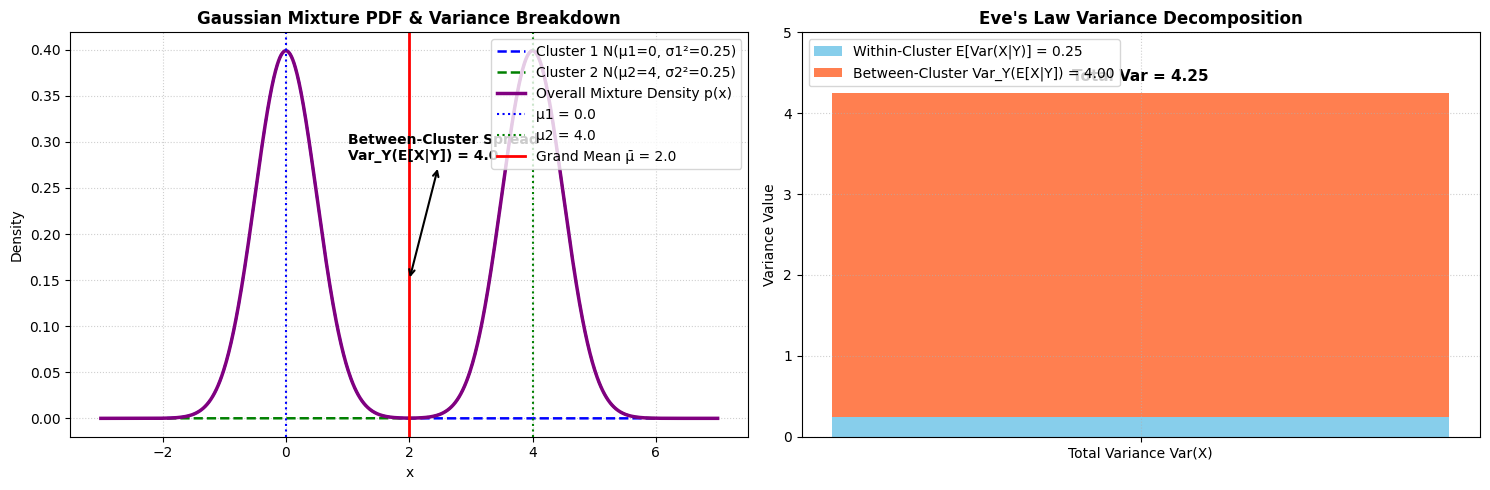

📊 Law of Total Variance (Eve's Law) Decomposition:
   Within-Cluster Variance  E[Var(X|Y)]:   0.2500
   Between-Cluster Variance Var(E[X|Y]):   4.0000
   Total Analytical Variance Var(X):       4.2500


In [15]:
#Start code here...
#Law of Total variance decomposition for Gaussian mixture models
pi1, pi2 = 0.5,0.5
mu1, sigma1 = 0.0, 0.5
mu2, sigma2 = 4.0, 0.5

#calculate the grand mean
mu_bar = pi1*mu1 + pi2*mu2
#Within cluster : average of individual cluster variances
within_var = pi1 * (sigma1**2) + pi2 * (sigma2**2)
#Between cluster : variance of the cluster centroids
between_var = pi1 * ((mu1 - mu_bar)**2) + pi2 * ((mu2 - mu_bar)**2)
total_var_analytical = within_var + between_var


##End code here..

# Generate Visual Diagram
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Gaussian Mixture Distribution Curves
x_grid = np.linspace(-3, 7, 1000)
g1 = pi1 * stats.norm.pdf(x_grid, mu1, sigma1)
g2 = pi2 * stats.norm.pdf(x_grid, mu2, sigma2)
g_total = g1 + g2

axes[0].plot(x_grid, g1, color='blue', linestyle='--', linewidth=1.8, label="Cluster 1 N(μ1=0, σ1²=0.25)")
axes[0].plot(x_grid, g2, color='green', linestyle='--', linewidth=1.8, label="Cluster 2 N(μ2=4, σ2²=0.25)")
axes[0].plot(x_grid, g_total, color='purple', linewidth=2.5, label="Overall Mixture Density p(x)")

# Mark Component Centroids and Grand Mean
axes[0].axvline(mu1, color='blue', linestyle=':', label="μ1 = 0.0")
axes[0].axvline(mu2, color='green', linestyle=':', label="μ2 = 4.0")
axes[0].axvline(mu_bar, color='red', linestyle='-', linewidth=2, label="Grand Mean μ̄ = 2.0")

# Annotate Within vs Between Spread
axes[0].annotate("Between-Cluster Spread\nVar_Y(E[X|Y]) = 4.0", xy=(2.0, 0.15), xytext=(1.0, 0.28),
             arrowprops=dict(facecolor='black', arrowstyle='<->', lw=1.5), fontsize=10, fontweight='bold')
axes[0].set_title("Gaussian Mixture PDF & Variance Breakdown", fontweight='bold')
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Stacked Bar Chart of Total Variance Breakdown
categories = ["Total Variance Var(X)"]
axes[1].bar(categories, [within_var], color='skyblue', label=f"Within-Cluster E[Var(X|Y)] = {within_var:.2f}")
axes[1].bar(categories, [between_var], bottom=[within_var], color='coral', label=f"Between-Cluster Var_Y(E[X|Y]) = {between_var:.2f}")

axes[1].set_ylabel("Variance Value")
axes[1].set_title("Eve's Law Variance Decomposition", fontweight='bold')
axes[1].set_ylim(0, 5.0)
axes[1].text(0, total_var_analytical + 0.15, f"Total Var = {total_var_analytical:.2f}", ha='center', fontweight='bold', fontsize=11)
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("📊 Law of Total Variance (Eve's Law) Decomposition:")
print(f"   Within-Cluster Variance  E[Var(X|Y)]:   {within_var:.4f}")
print(f"   Between-Cluster Variance Var(E[X|Y]):   {between_var:.4f}")
print(f"   Total Analytical Variance Var(X):       {total_var_analytical:.4f}")


## 7️⃣ Anscombe's Quartet: Summary Statistics vs. Visualization

### 7.1 Methodological Insight
In 1973, statistician Francis Anscombe constructed four synthetic datasets. Each dataset consists of 11 $(x, y)$ pairs sharing **virtually identical summary statistics**:
- Mean of $X = 9.0$, Mean of $Y = 7.50$
- Variance of $X = 11.0$, Variance of $Y = 4.125$
- Linear Regression Fit: $y = 3.0 + 0.50x$
- Pearson Correlation Coefficient $r = 0.816$

Despite identical summary statistics, plotting the datasets reveals vastly different structural behaviors (linear trend, quadratic curve, outlier influence, vertical cluster).

Anscombe's quartet summary statistics across groups
         mean_x  var_x  mean_y  var_y
dataset                              
I           9.0   11.0   7.501  4.127
II          9.0   11.0   7.501  4.128
III         9.0   11.0   7.500  4.123
IV          9.0   11.0   7.501  4.123


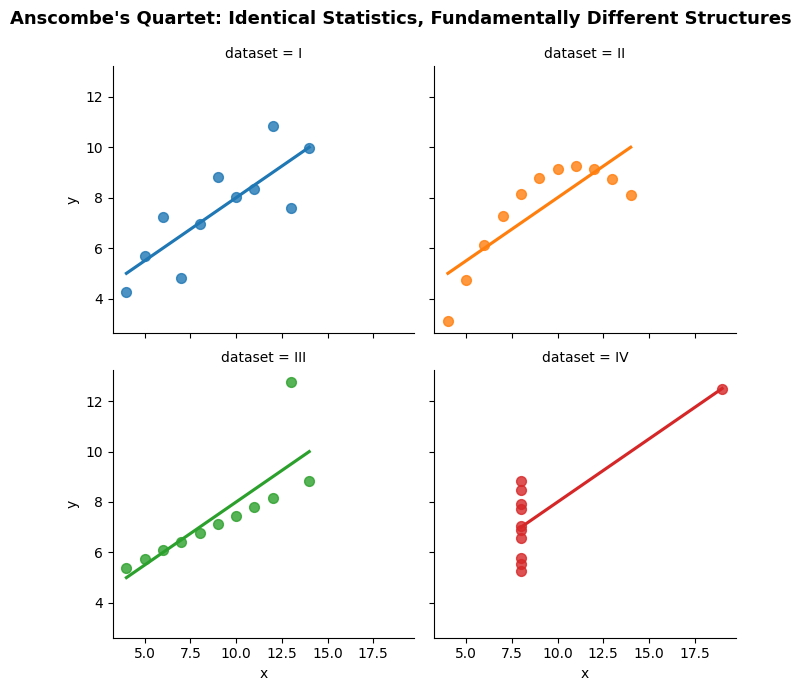

In [16]:
#Start code here..
#visualizing Anscombe's quartet using seaborn
df_anscombe = sns.load_dataset("anscombe")

#display the summary statistics per dataset showing that they are nearly identical
print("Anscombe's quartet summary statistics across groups")
stats_df = df_anscombe.groupby("dataset").agg(
    mean_x = ("x", "mean"),
    var_x = ("x", "var"),
    mean_y = ("y", "mean"),
    var_y = ("y", "var")
).round(3)
print(stats_df)

#End code here..

# Plotting the 4 Datasets
sns.lmplot(
    data=df_anscombe, x="x", y="y", col="dataset", hue="dataset",
    col_wrap=2, ci=None, height=3.5, scatter_kws={"s": 50, "alpha": 0.8}
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Anscombe's Quartet: Identical Statistics, Fundamentally Different Structures", fontsize=13, fontweight='bold')
plt.show()


## 8️⃣ Master Summary Table
Below is a structured recap of the core probabilistic principles covered in Lecture 5.

In [17]:
# Master Concept Summary Table
summary_data = {
    "Concept": [
        "Frequentist Probability",
        "Bayesian Probability",
        "Active Learning Querying",
        "Conditional Independence",
        "Quantile Function (F^-1)",
        "Gaussian 95% Interval",
        "Product Variance Var(XY)",
        "Law of Total Variance",
        "Anscombe's Quartet"
    ],
    "Mathematical Formulation": [
        "lim_{N->inf} N_A / N",
        "P(A | H) in [0, 1]",
        "argmax_x H(Y | x) = -sum p log_2 p",
        "P(A, B | C) = P(A | C) P(B | C)",
        "x_q = F^-1(q) s.t. P(X <= x_q) = q",
        "[mu - 1.96*sigma, mu + 1.96*sigma]",
        "(Var(X)+mu_X^2)(Var(Y)+mu_Y^2) - mu_X^2 mu_Y^2",
        "Var(X) = E[Var(X|Y)] + Var(E[X|Y])",
        "Identical E[X], Var(X), r; Different Spatial Structures"
    ],
    "Key Takeaway / Application": [
        "Requires repeated physical trials under identical conditions",
        "Models subjective belief / single-instance event uncertainty",
        "Queries instances with highest epistemic model uncertainty",
        "Basis for Probabilistic Graphical Models (PGM) & Naive Bayes",
        "Maps cumulative probability q back to feature domain value",
        "Contains 95% of total probability mass for normal distribution",
        "Computes spread of product of independent random variables",
        "Decomposes GMM variance into within- vs between-cluster",
        "Low-order statistics can deceive; ALWAYS visualize data"
    ]
}

df_master = pd.DataFrame(summary_data)
print("📌 Lecture 5 Master Summary Table:")
print(df_master.to_string(index=False))


📌 Lecture 5 Master Summary Table:
                 Concept                                Mathematical Formulation                                     Key Takeaway / Application
 Frequentist Probability                                    lim_{N->inf} N_A / N   Requires repeated physical trials under identical conditions
    Bayesian Probability                                      P(A | H) in [0, 1]   Models subjective belief / single-instance event uncertainty
Active Learning Querying                      argmax_x H(Y | x) = -sum p log_2 p     Queries instances with highest epistemic model uncertainty
Conditional Independence                         P(A, B | C) = P(A | C) P(B | C)   Basis for Probabilistic Graphical Models (PGM) & Naive Bayes
Quantile Function (F^-1)                      x_q = F^-1(q) s.t. P(X <= x_q) = q     Maps cumulative probability q back to feature domain value
   Gaussian 95% Interval                      [mu - 1.96*sigma, mu + 1.96*sigma] Contains 95% of total